In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np 
import os

from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from matplotlib.lines import Line2D
from PIL import Image


sns.set_context("talk")


In [2]:
data_directory="../result/lammps/annealing/2nm/vashishta/result/"

df_list=list()
for file in os.listdir(data_directory):
    if not "csv" in file:
        continue
    df_tmp=pd.read_csv(os.path.join(data_directory,file),index_col=False).rename(columns={
    "temperature":"Temperature (K)"
    ,"pressure":"Pressure (bars)"
    ,"vol":"Volume ($Å^3$)"
    })
    df_tmp["Time (ns)"]=df_tmp["time step"]*1e-6
    df_list.append(df_tmp)
    
df_thermo=pd.concat(df_list,ignore_index=True)
df_thermo


,time step,Temperature (K),Pressure (bars),potential energy,kinetic energy,coulomb energy,pair energy,lx,ly,lz,Volume ($Å^3$),Time (ns)
0,350000,4988.167506,2475.932757,-91238.897828,7519.967148,0,-91238.897828,65.897503,57.068911,54.433093,204706.464573,0.3500
1,350500,4913.788113,-1590.308850,-91455.153175,7407.835672,0,-91455.153175,65.828188,57.008883,54.375837,204061.180680,0.3505
2,351000,4927.779653,4305.064630,-91665.406032,7428.928772,0,-91665.406032,65.376411,56.617632,54.002657,199888.546057,0.3510
3,351500,4850.487093,-1229.142229,-91652.731094,7312.405517,0,-91652.731094,65.479095,56.706559,54.087477,200831.894146,0.3515
4,352000,4831.156246,-2648.702415,-91830.489019,7283.263086,0,-91830.489019,65.583363,56.796858,54.173605,201792.833383,0.3520
...,...,...,...,...,...,...,...,...,...,...,...,...
702,298000,4965.034847,-2331.286662,-91463.066262,7485.093253,0,-91463.066262,65.735694,56.928781,54.299435,203202.216795,0.2980
703,298500,4991.421348,997.355749,-91375.593974,7524.872513,0,-91375.593974,65.735694,56.928781,54.299435,203202.216795,0.2985
704,299000,5014.837895,3832.645829,-91452.817690,7560.174389,0,-91452.817690,65.735694,56.928781,54.299435,203202.216795,0.2990
705,299500,4958.844706,2738.076756,-91526.092289,7475.761236,0,-91526.092289,65.735694,56.928781,54.299435,203202.216795,0.2995


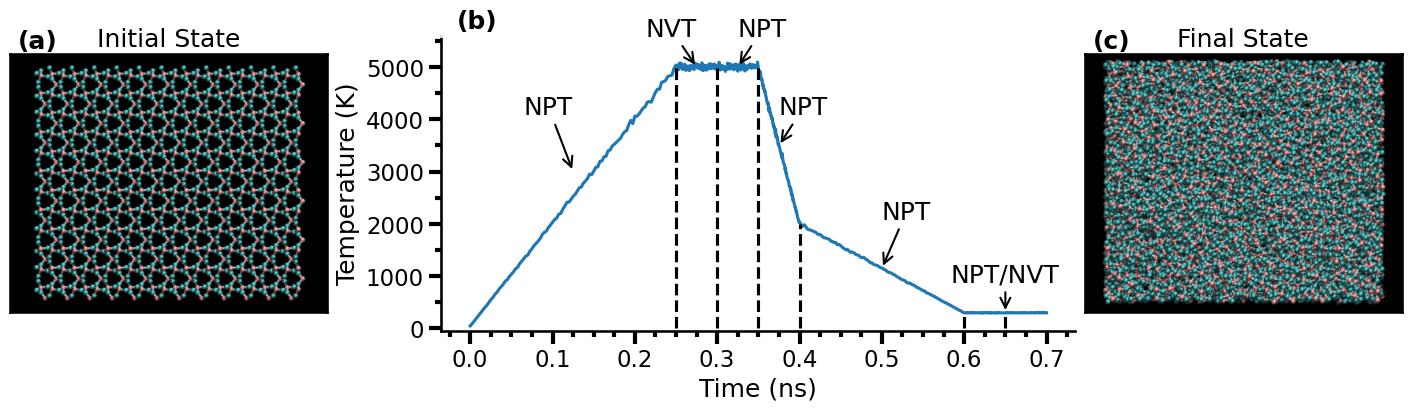

In [34]:
fig, axs = plt.subplots(ncols=3,figsize=(7*2,4),width_ratios=(1,2,1),constrained_layout = True
                       )

sns.set_context("talk")


labx=0.025
laby=1.025

ax=axs[1]
ax.text(labx, laby, '(b)',weight='bold' ,transform=ax.transAxes)

sns.lineplot(data=df_thermo
    , y='Temperature (K)'
             , x='Time (ns)'
             ,ax=ax
            )
ax.spines['bottom'].set_color('0')
ax.spines['top'].set_color('1')
ax.spines['right'].set_color('1')
ax.spines['left'].set_color('0')
ax.tick_params(direction='out', width=3, bottom=True, left=True)
ax.tick_params(which='minor', length=4,width=3)
ax.xaxis.set_minor_locator(MultipleLocator(0.1/4))
ax.yaxis.set_minor_locator(MultipleLocator(2000/4))

ax.grid(False)


ax.vlines(x=0.25, ymin=0, ymax=5000,linestyles='--',colors="black")
ax.annotate("NPT", xy=(0.125, 3000), xytext=(0.125, 4000), arrowprops=dict(arrowstyle="->",color="black"),ha='right',va='bottom')

ax.vlines(x=0.3, ymin=0, ymax=5000,linestyles='--',colors="black")
ax.annotate("NVT", xy=(0.275, 5000), xytext=(0.275, 5500), arrowprops=dict(arrowstyle="->",color="black"),ha='right',va='bottom')

ax.vlines(x=0.35, ymin=0, ymax=5000,linestyles='--',colors="black")
ax.annotate("NPT", xy=(0.325, 5000), xytext=(0.325, 5500), arrowprops=dict(arrowstyle="->",color="black"),ha='left',va='bottom')

ax.vlines(x=0.40, ymin=0, ymax=2000,linestyles='--',colors="black")
ax.annotate("NPT", xy=(0.375, 3500), xytext=(0.375, 4000), arrowprops=dict(arrowstyle="->",color="black"),ha='left',va='bottom')

ax.vlines(x=0.60, ymin=0, ymax=300,linestyles='--',colors="black")
ax.annotate("NPT", xy=(0.5, 1150), xytext=(0.5, 2000), arrowprops=dict(arrowstyle="->",color="black"),ha='left',va='bottom')

ax.vlines(x=0.65, ymin=0, ymax=300,linestyles='--',colors="black")
ax.annotate("NPT/NVT", xy=(0.65, 300), xytext=(0.65, 800), arrowprops=dict(arrowstyle="->",color="black"),ha='center',va='bottom')

ax.set_ylim(-50,5600)


label_index=list("ac")
for i,state in enumerate(["initial","final"]):
    ax=axs[2*i]
    ax.text(labx, laby, '(%s)'%label_index[i],weight='bold' ,transform=ax.transAxes)
    ax.set_title("%s State"%state.capitalize())
    img = np.asarray(Image.open('../figures/structures/%s.png'%(state)))
    ax.imshow(img)
    ax.set_yticks([])
    ax.set_xticks([])



plt.savefig("../figures/fig1.pdf", pad_inches=0.2,bbox_inches="tight")

49.99999999999999